# How to create branches for parallel node execution

LangGraph natively supports fan-out and fan-in using either regular edges or [conditional_edges](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.MessageGraph.add_conditional_edges).

This lets you run nodes in parallel to speed up your total graph execution.

Below are some examples showing how to add create branching dataflows that work for you. 

In [ ]:
# DEPENDENCY: pip install --quiet -U langchain langchain-openai langchain-community langchain-text-splitters langgraph langgraph-prebuilt langgraph-checkpoint-sqlite langsmith ddgs
# (packages should be pre-installed in venv before running this script)


In [ ]:
import getpass
import os
import warnings

from openai import OpenAI

# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="langchain")

# Set up your OpenAI client
if not os.getenv("OPENAI_API_KEY"):
    secret_key = os.environ.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = secret_key

## Parallel node fan-out and fan-in

In [2]:
import operator
from typing import Annotated, Any

from typing_extensions import TypedDict
from langgraph.graph import StateGraph


class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]


class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.set_entry_point("a")
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.set_finish_point("d")
graph = builder.compile()

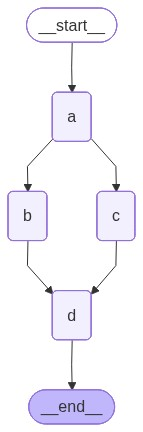

In [3]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
graph.invoke({"aggregate": []}, {"configurable": {"thread_id": "foo"}})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'aggregate': ["I'm A", "I'm B", "I'm C", "I'm D"]}

<details class="note"> <summary>Exception handling?</summary>
 <p>LangGraph executes nodes within <a href="https://langchain-ai.github.io/langgraph/concepts/#core-design">"supersteps"</a>, meaning that while parallel branches are executed in parallel, the entire superstep is <b>transactional</b>. If any of these branches raises an exception, <b>none</b> of the updates are applied to the state (the entire superstep errors).<br><br>
 If you have error-prone (perhaps want to handle flakey API calls), LangGraph provides two ways to address this:<br>
 <ol>
  <li>You can write regular python code within your node to catch and handle exceptions.</li>
  <li>You can set a <b><a href="https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.graph.CompiledGraph.retry_policy">retry_policy</a></b> to direct the graph to retry nodes that raise certain types of exceptions. Only failing branches are retried, so you needn't worry about performing redundant work.</li>
</ol></p>
Together, these let you perform parallel execution and fully control exception handling.
</details>

## Parallel node fan-out and fan-in with extra steps

The above example showed how to fan-out and fan-in when each path was only one step. But what if one path had more than one step?

In [5]:
import operator
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph


class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]


builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.set_entry_point("a")
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.set_finish_point("d")
graph = builder.compile()

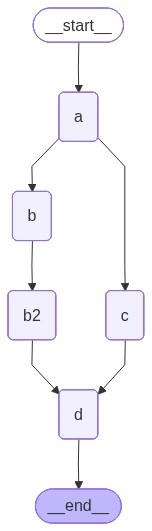

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke({"aggregate": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'aggregate': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

## Conditional Branching

If your fan-out is not deterministic, you can use [add_conditional_edges](https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.StateGraph.add_conditional_edges) directly.

If you have a known "sink" node that the conditional branches will route to afterwards, you can provide `then=<final-node-name>` when creating the conditional edges.

In [8]:
import operator
from typing import Annotated, Sequence

from typing_extensions import TypedDict

from langgraph.graph import END, START, StateGraph


class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]
    which: str


builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_edge(START, "a")
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_node("e", ReturnNodeValue("I'm E"))


def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]


intermediates = ["b", "c", "d"]
builder.add_conditional_edges(
    "a",
    route_bc_or_cd,
    intermediates,
)
for node in intermediates:
    builder.add_edge(node, "e")


builder.add_edge("e", END)
graph = builder.compile()

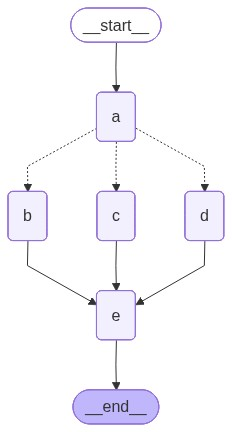

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"aggregate": [], "which": "bc"})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm E to ["I'm A", "I'm B", "I'm C"]


{'aggregate': ["I'm A", "I'm B", "I'm C", "I'm E"], 'which': 'bc'}

In [11]:
graph.invoke({"aggregate": [], "which": "cd"})

Adding I'm A to []
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A"]
Adding I'm E to ["I'm A", "I'm C", "I'm D"]


{'aggregate': ["I'm A", "I'm C", "I'm D", "I'm E"], 'which': 'cd'}

## Stable Sorting

When fanned out, nodes are run in parallel as a single "superstep". The updates from each superstep are all applied to the state in sequence once the superstep has completed. 

If you need consistent, predetermined ordering of updates from a parallel superstep, you should write the outputs (along with an identifying key) to a separate field in your state, then combine them in the "sink" node by adding regular `edge`'s from each of the fanout nodes to the rendezvous point.

For instance, suppose I want to order the outputs of the parallel step by "reliability".

In [12]:
import operator
from typing import Annotated, Sequence

from typing_extensions import TypedDict

from langgraph.graph import StateGraph


def reduce_fanouts(left, right):
    if left is None:
        left = []
    if not right:
        # Overwrite
        return []
    return left + right


class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]
    fanout_values: Annotated[list, reduce_fanouts]
    which: str


builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.set_entry_point("a")


class ParallelReturnNodeValue:
    def __init__(
        self,
        node_secret: str,
        reliability: float,
    ):
        self._value = node_secret
        self._reliability = reliability

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']} in parallel.")
        return {
            "fanout_values": [
                {
                    "value": [self._value],
                    "reliability": self._reliability,
                }
            ]
        }


builder.add_node("b", ParallelReturnNodeValue("I'm B", reliability=0.9))

builder.add_node("c", ParallelReturnNodeValue("I'm C", reliability=0.1))
builder.add_node("d", ParallelReturnNodeValue("I'm D", reliability=0.3))


def aggregate_fanout_values(state: State) -> Any:
    # Sort by reliability
    ranked_values = sorted(
        state["fanout_values"], key=lambda x: x["reliability"], reverse=True
    )
    return {
        "aggregate": [x["value"] for x in ranked_values] + ["I'm E"],
        "fanout_values": [],
    }


builder.add_node("e", aggregate_fanout_values)


def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]


intermediates = ["b", "c", "d"]
builder.add_conditional_edges("a", route_bc_or_cd, intermediates)

for node in intermediates:
    builder.add_edge(node, "e")

builder.set_finish_point("e")
graph = builder.compile()

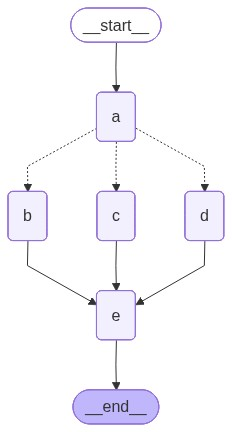

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
graph.invoke({"aggregate": [], "which": "bc", "fanout_values": []})

Adding I'm A to []
Adding I'm B to ["I'm A"] in parallel.
Adding I'm C to ["I'm A"] in parallel.


{'aggregate': ["I'm A", ["I'm B"], ["I'm C"], "I'm E"],
 'fanout_values': [],
 'which': 'bc'}

In [15]:
graph.invoke({"aggregate": [], "which": "cd"})

Adding I'm A to []
Adding I'm C to ["I'm A"] in parallel.
Adding I'm D to ["I'm A"] in parallel.


{'aggregate': ["I'm A", ["I'm D"], ["I'm C"], "I'm E"],
 'fanout_values': [],
 'which': 'cd'}